# 🎓 Student Dropout Predictor — Exploratory Data Analysis
> **Purpose:** Understand the dataset thoroughly *before* applying any Machine Learning.  
> Dataset: `data/students.csv` — 1,000 students · 5 features · 1 binary target (`dropout`)


## 1. Load Dataset
Import the required libraries and load `students.csv` into a Pandas DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook-wide display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline

# ── Load the dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('data/students.csv')

print(f"✅ Dataset loaded successfully.")
print(f"   Rows   : {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")
print(f"   Columns: {list(df.columns)}")


✅ Dataset loaded successfully.
   Rows   : 1000
   Columns: 6
   Columns: ['attendance', 'marks', 'assignments', 'tests', 'participation', 'dropout']


## 2. Inspect Dataset
Preview rows and get statistical summaries.

In [2]:
# ── First 5 rows ──────────────────────────────────────────────────────────────
print("── df.head() ──")
df.head()


── df.head() ──


,attendance,marks,assignments,tests,participation,dropout
0,88.1,63.1,70.3,100.0,72.0,0
1,87.4,67.0,71.9,97.0,52.5,0
2,94.2,82.0,83.4,72.2,75.0,0
3,67.4,68.6,100.0,67.6,52.1,0
4,90.7,80.8,85.4,77.0,53.2,0


In [3]:
# ── Statistical Summary ───────────────────────────────────────────────────────
print("── df.describe() ──")
df.describe().round(2)


── df.describe() ──


,attendance,marks,assignments,tests,participation,dropout
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.0
mean,76.41,68.35,77.23,70.77,69.77,0.2
std,20.23,20.21,24.30,20.21,24.70,0.4
min,0.00,0.00,0.00,0.00,0.00,0.0
25%,71.20,59.58,73.47,59.88,58.78,0.0
50%,81.85,72.60,85.20,73.50,75.50,0.0
75%,89.70,81.72,93.00,85.20,87.50,0.0
max,100.00,100.00,100.00,100.00,100.00,1.0


In [4]:
# ── Data Types & Info ─────────────────────────────────────────────────────────
print("── df.info() ──")
df.info()


── df.info() ──
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   attendance     1000 non-null   float64
 1   marks          1000 non-null   float64
 2   assignments    1000 non-null   float64
 3   tests          1000 non-null   float64
 4   participation  1000 non-null   float64
 5   dropout        1000 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 47.0 KB


## 3. Check Missing Values
Identify any nulls in the dataset. Missing data must be handled before training.

In [5]:
# ── Missing value count per column ───────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print("── df.isnull().sum() ──")
print(missing_report)

if missing.sum() == 0:
    print("\n✅ No missing values found! Dataset is clean.")
else:
    print(f"\n⚠️  Total missing cells: {missing.sum()}")


── df.isnull().sum() ──
               Missing Count  Missing %
attendance                 0        0.0
marks                      0        0.0
assignments                0        0.0
tests                      0        0.0
participation              0        0.0
dropout                    0        0.0

✅ No missing values found! Dataset is clean.


── Class Distribution ──
  Not at Risk (0): 800  (80.0%)
  At Risk     (1): 200  (20.0%)


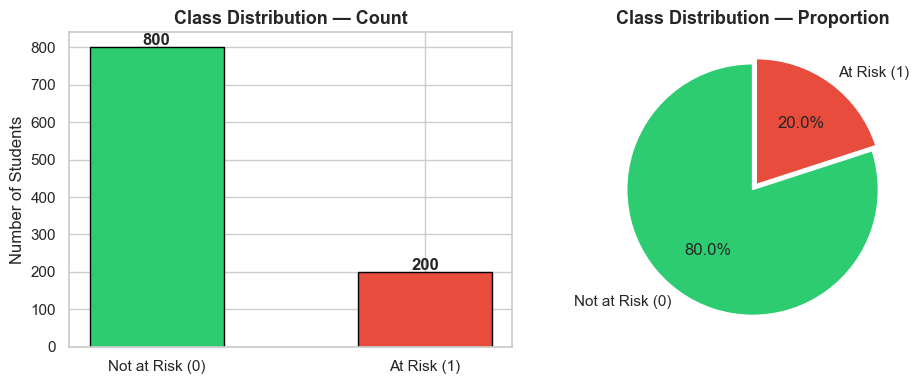

In [6]:
# ── Target Class Distribution ─────────────────────────────────────────────────
class_counts = df['dropout'].value_counts()
class_pct    = df['dropout'].value_counts(normalize=True) * 100

print("── Class Distribution ──")
print(f"  Not at Risk (0): {class_counts[0]}  ({class_pct[0]:.1f}%)")
print(f"  At Risk     (1): {class_counts[1]}  ({class_pct[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count bar
axes[0].bar(['Not at Risk (0)', 'At Risk (1)'], class_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Not at Risk (0)', 'At Risk (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Class Distribution — Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Visualize Correlations
Heatmaps and distribution plots reveal which features are most predictive of dropout.

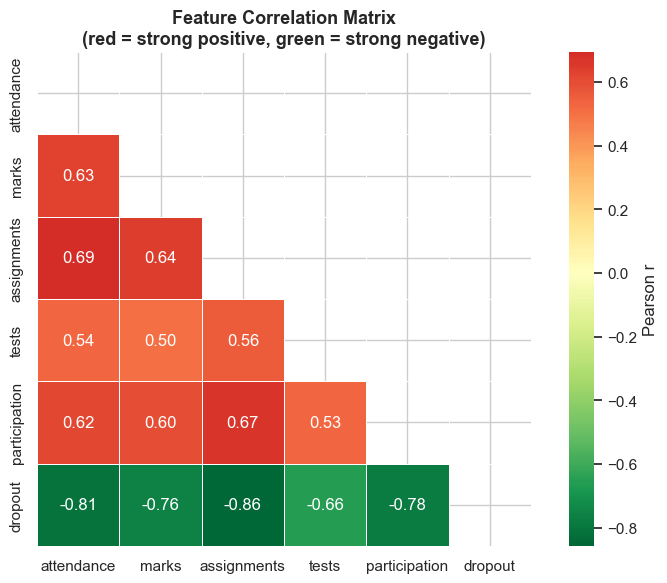


── Correlation with target (dropout) ──
assignments     -0.857
attendance      -0.810
participation   -0.784
marks           -0.756
tests           -0.656


In [7]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # show lower triangle only
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Pearson r'}
)
plt.title('Feature Correlation Matrix\n(red = strong positive, green = strong negative)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n── Correlation with target (dropout) ──")
print(corr_matrix['dropout'].drop('dropout').sort_values().round(3).to_string())


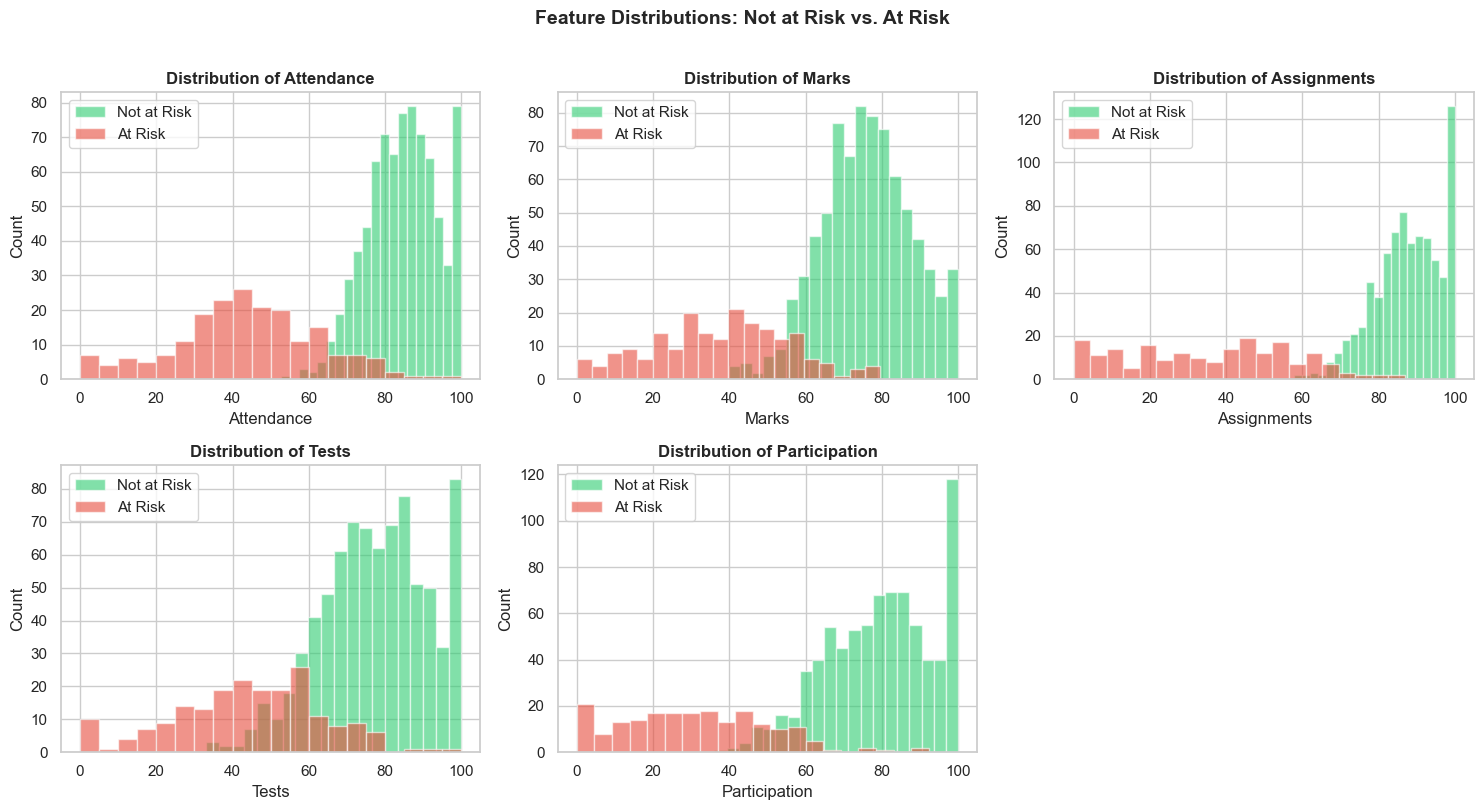

In [8]:
# ── Feature Distributions by Dropout Status ──────────────────────────────────
features = ['attendance', 'marks', 'assignments', 'tests', 'participation']
colors   = {0: '#2ecc71', 1: '#e74c3c'}
labels   = {0: 'Not at Risk', 1: 'At Risk'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for cls in [0, 1]:
        subset = df[df['dropout'] == cls][feat]
        axes[i].hist(subset, bins=20, alpha=0.6,
                     color=colors[cls], label=labels[cls], edgecolor='white')
    axes[i].set_title(f'Distribution of {feat.capitalize()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feat.capitalize())
    axes[i].set_ylabel('Count')
    axes[i].legend()

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Feature Distributions: Not at Risk vs. At Risk',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


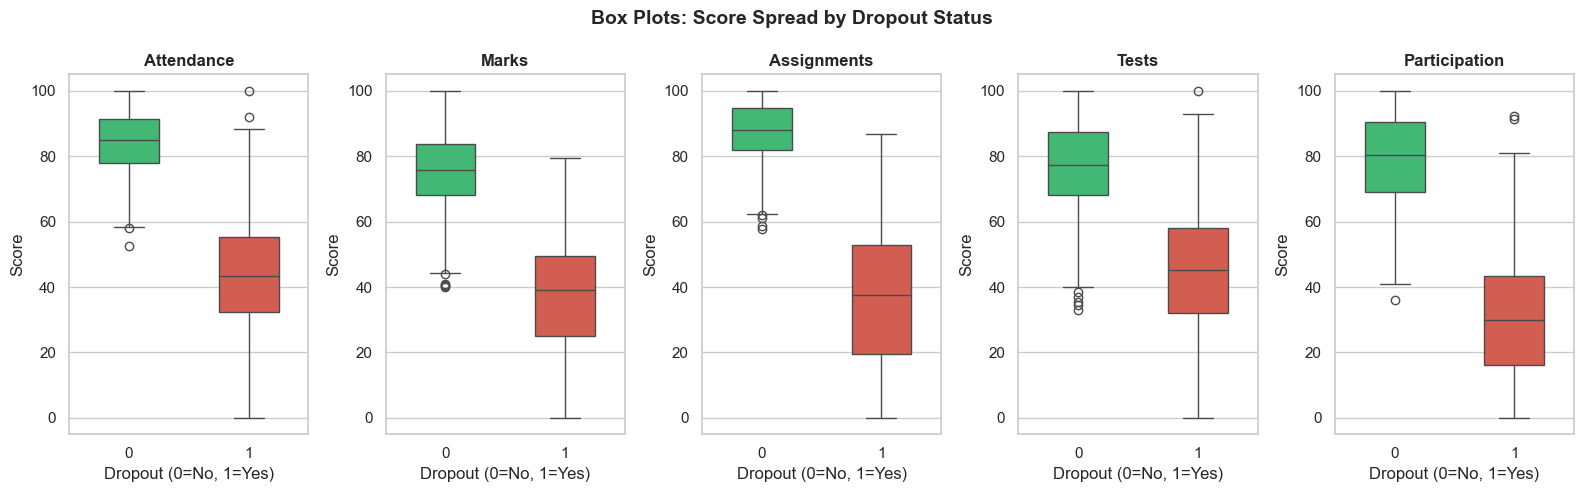

In [10]:
# ── Box Plots: Feature spread per class ──────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 5), sharey=False)

for i, feat in enumerate(features):
    sns.boxplot(
        data=df,
        x='dropout',
        y=feat,
        hue='dropout',
        palette=['#2ecc71', '#e74c3c'],
        width=0.5,
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(feat.capitalize(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Dropout (0=No, 1=Yes)')
    axes[i].set_ylabel('Score')

plt.suptitle('Box Plots: Score Spread by Dropout Status',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


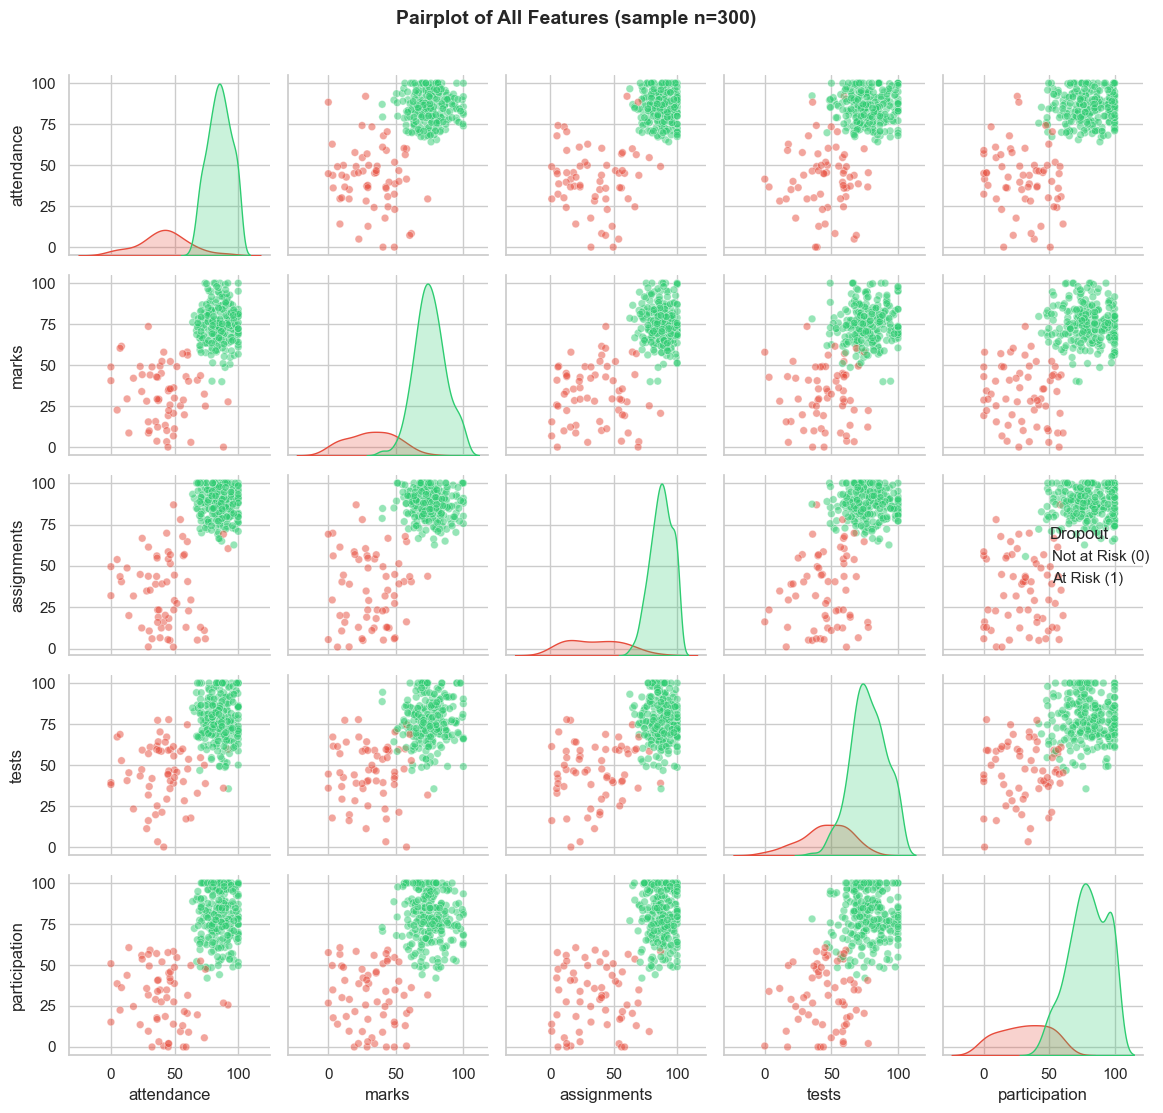

In [11]:
# ── Pairplot: Feature-vs-Feature coloured by target ──────────────────────────
sample_df = df.sample(n=300, random_state=42)  # use a sample for speed

pair = sns.pairplot(
    sample_df,
    hue='dropout',
    palette={0: '#2ecc71', 1: '#e74c3c'},
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 30},
    height=2.2
)
pair.fig.suptitle('Pairplot of All Features (sample n=300)',
                  fontsize=14, fontweight='bold', y=1.01)

# Rename legend labels
handles = pair.legend.legend_handles
pair.legend.set_title('Dropout')
for handle, label in zip(handles, ['Not at Risk (0)', 'At Risk (1)']):
    handle.set_label(label)
pair.legend.get_texts()[0].set_text('Not at Risk (0)')
pair.legend.get_texts()[1].set_text('At Risk (1)')

plt.tight_layout()
plt.show()


## 5. Key Insights Summary

| Finding | Detail |
|---------|--------|
| **Dataset size** | 1,000 students, 5 numeric features + 1 binary target |
| **Class balance** | ~80% Not at Risk · ~20% At Risk (imbalanced — keep in mind for modelling) |
| **Missing values** | None — dataset is clean |
| **Most predictive features** | `attendance`, `marks`, and `participation` show the highest negative correlation with dropout |
| **Clear separation** | Box plots & pairplot show well-separated clusters → ML model should perform well |

> **Next step:** Build and train a classification model (`model/train.py`).
